# Florentine families

In [1]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))

from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *


## Network

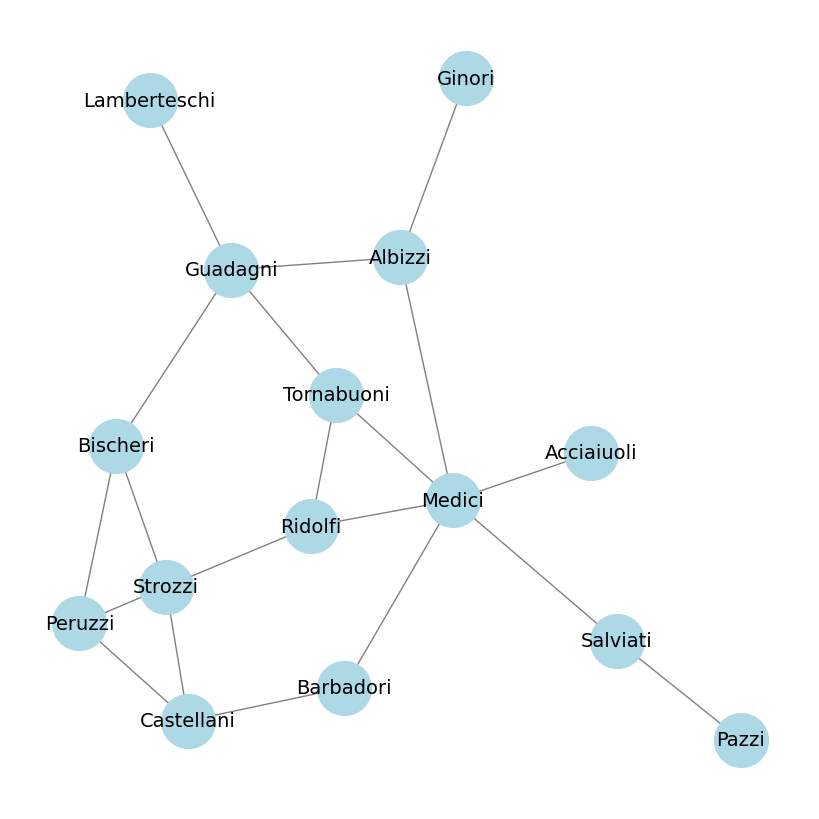

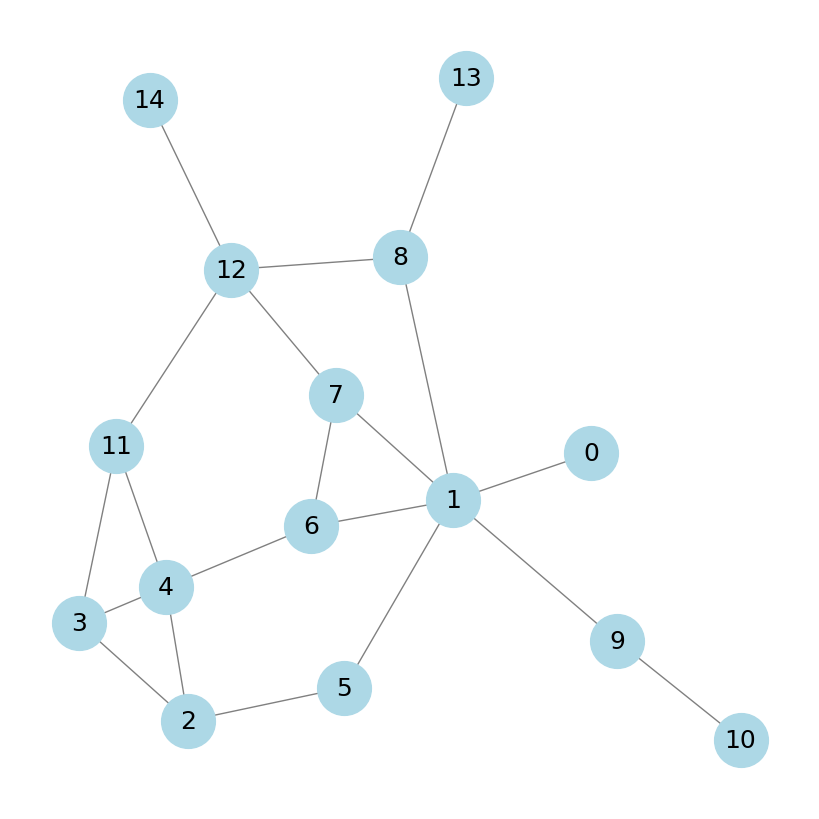

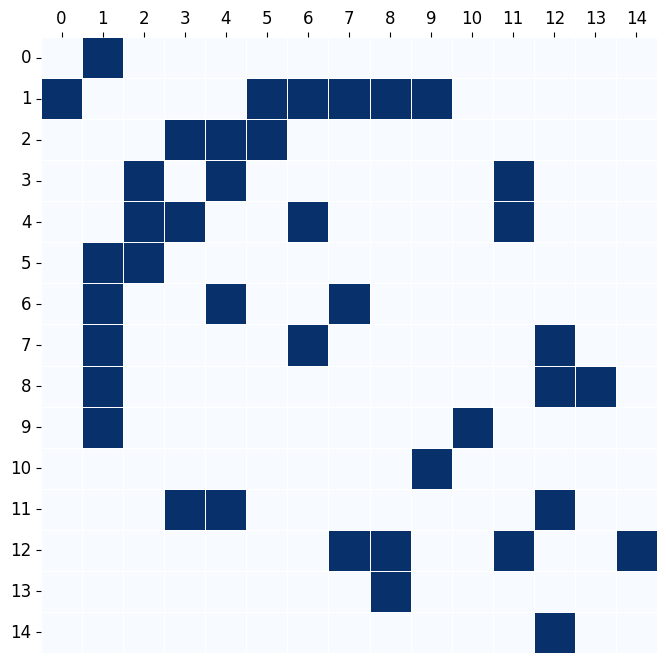

In [2]:
G = nx.florentine_families_graph()
pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(8,8))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=14)
#plt.title("Florentine Families network")
plt.show()

G = nx.florentine_families_graph()
node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
plt.figure(figsize=(8,8))
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
nx.draw(G,  pos=pos_relabel, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=18)
#plt.title("Florentine Families network with relabeled nodes")
plt.show()
#print("Map from original nodes to new nodes:")
#print(node_mapping)

Y = nx.to_numpy_array(G, dtype=float)
n = Y.shape[0]
plt.figure(figsize=(8,8))
sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top() 
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=12)
#plt.title("Sociomatrix for Florentine families")
plt.show() 

In [3]:
seed_MAP = 42
diam = 20.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 5
n_iter_MAP = 25000
n_sim_iv = 2500
n_iter_cv = 2500
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### With weights

In [4]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R1_p.pkl")

Multi_start (5)


MAP:  17%|█▋        | 4254/25000 [00:57<04:38, 74.38it/s, logpost=-34.6788, loglik=-30.3226, logprior=-4.3562, patience=0]


KeyboardInterrupt: 

#### Without weights

Multi_start (5)


MAP:   5%|▌         | 1279/25000 [00:06<02:00, 197.43it/s, logpost=-43.8755, loglik=-42.7242, logprior=-1.1513, patience=49]


[STOP] Early stopping at iter 1279 (no improvement in 50 steps)


MAP:   5%|▌         | 1279/25000 [00:05<01:45, 224.40it/s, logpost=-43.8755, loglik=-42.7242, logprior=-1.1513, patience=49]


[STOP] Early stopping at iter 1279 (no improvement in 50 steps)


...

[STOP] Early stopping at iter 1279 (no improvement in 50 steps)


MAP:   5%|▌         | 1279/25000 [00:05<01:43, 229.57it/s, logpost=-43.8755, loglik=-42.7242, logprior=-1.1513, patience=49]


[STOP] Early stopping at iter 1279 (no improvement in 50 steps)


MAP:   5%|▌         | 1279/25000 [00:05<01:44, 227.48it/s, logpost=-43.8755, loglik=-42.7242, logprior=-1.1513, patience=49]


[STOP] Early stopping at iter 1279 (no improvement in 50 steps)

Best log-posterior: -43.8755


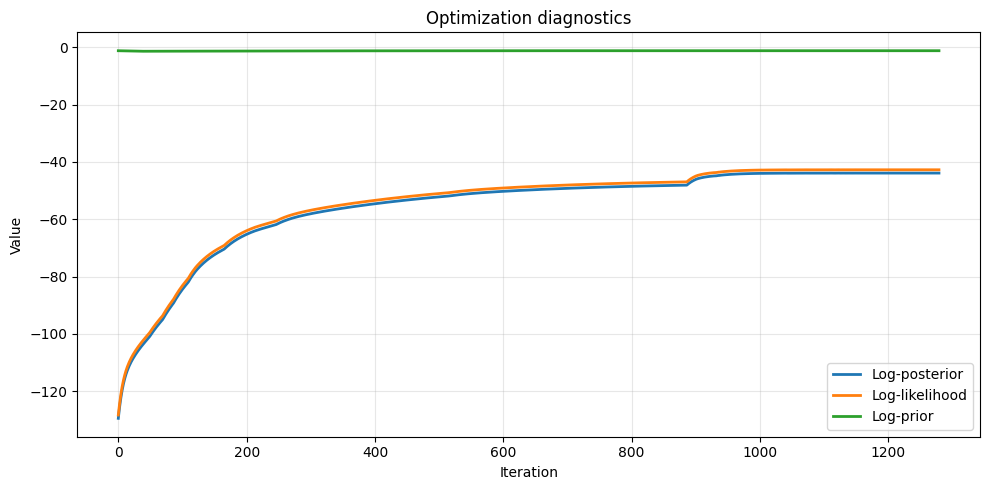

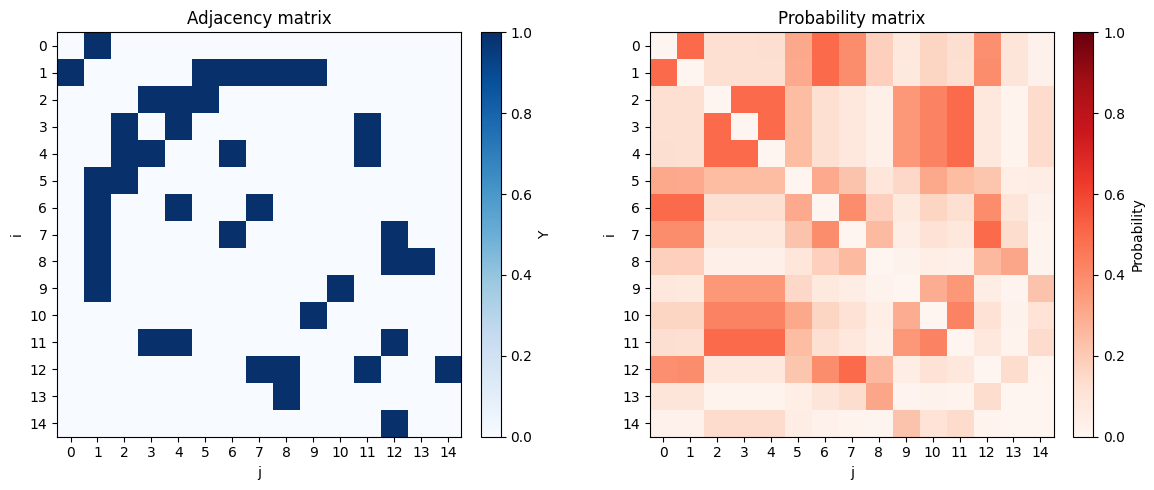

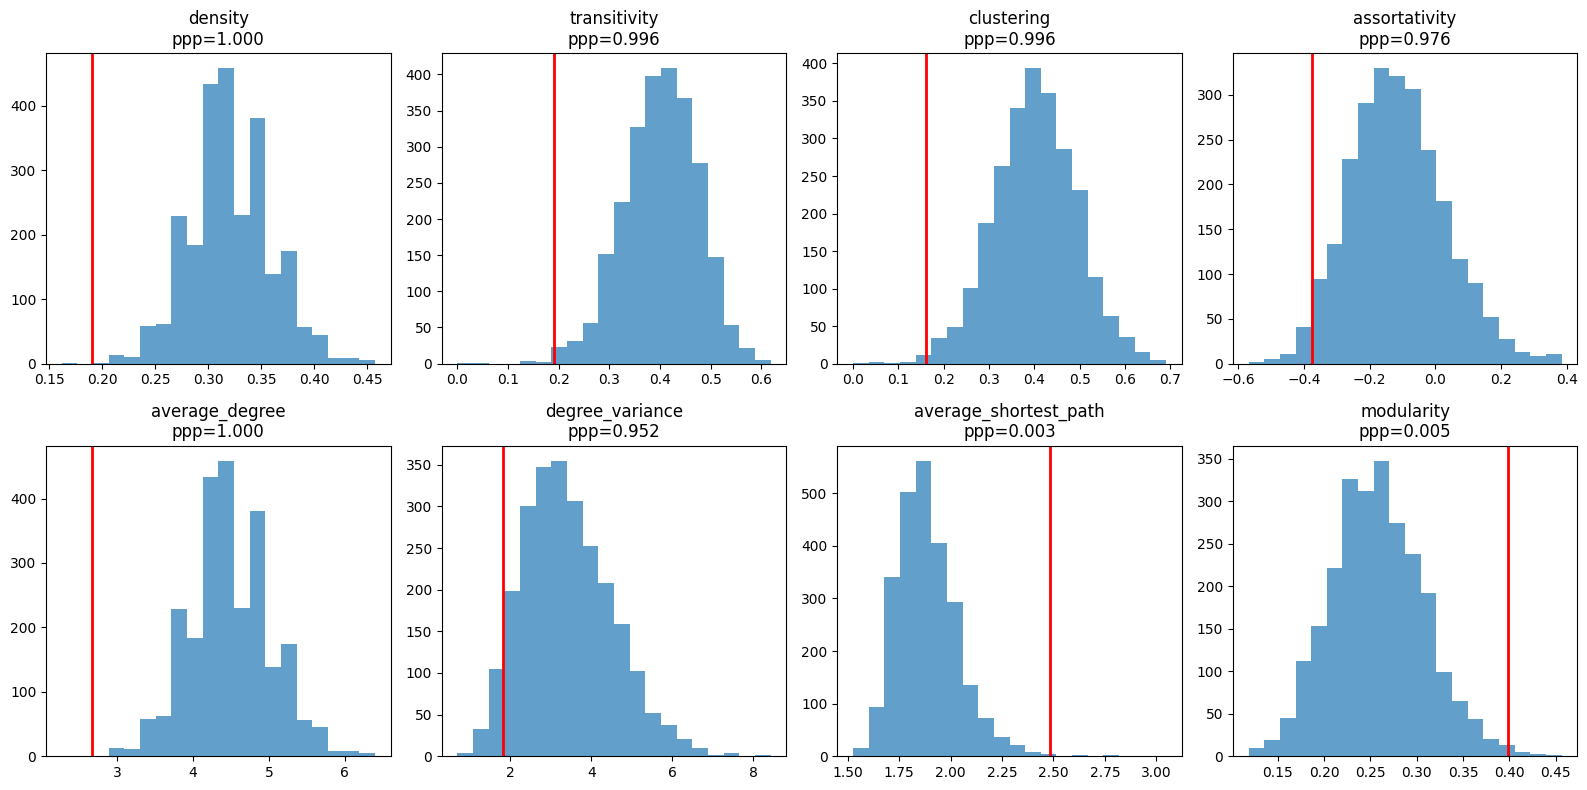

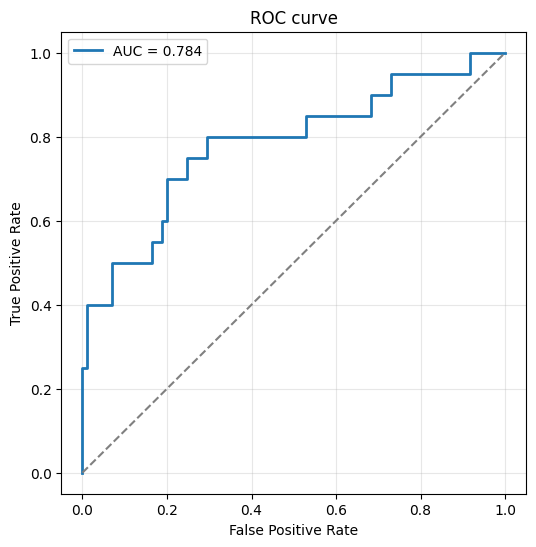

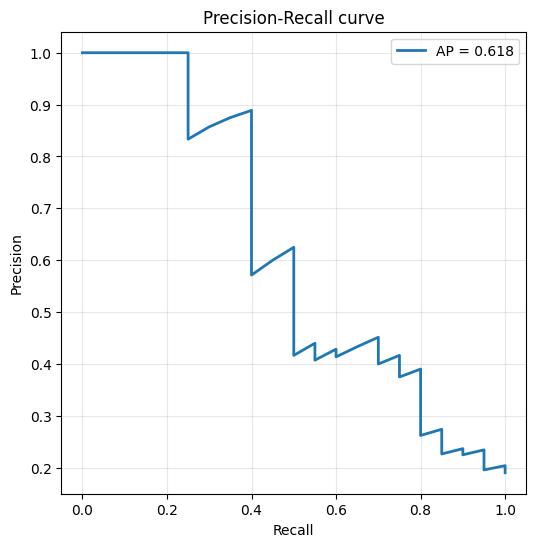

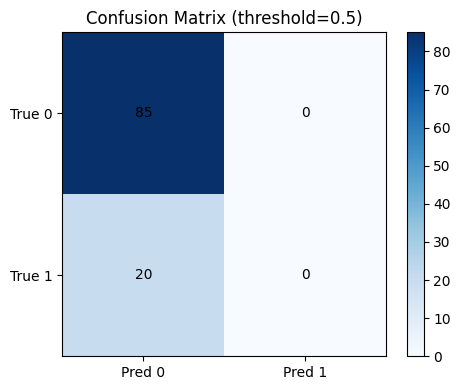

MAP:  92%|█████████▏| 2290/2500 [00:10<00:00, 224.03it/s, logpost=-28.4828, loglik=-27.3311, logprior=-1.1516, patience=49]


{'mean_auc': 0.6921425295264305, 'std_auc': 0.15046260397736186, 'min_auc': np.float64(0.5111111111111111), 'max_auc': np.float64(0.9473684210526316), 'n_folds': 5}


In [ ]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R1_c.pkl")

### Model $\mathbb{R}^2$

#### With weights

In [ ]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R2_p.pkl")

#### Without weigths

In [ ]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_R2_c.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### With weights

In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S1_p.pkl")

#### Without weights

In [ ]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S1_c.pkl")

### Model $\mathbb{S}^2$

#### With weights

In [ ]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S2_p.pkl")

#### Without weights

In [ ]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_S2_c.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### With weights

In [ ]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H1_p.pkl")

#### Without weights

In [ ]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H1_c.pkl")

### Model $\mathbb{H}^2$

#### With weights

In [ ]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry)
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H2_p.pkl")

#### Without weights

In [ ]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("Florentine_H2_c.pkl")

## Results

### Visualization of latent spaces 

### Visualization of probability matrices

### Model statistics

### Internal validation

### External validation